02-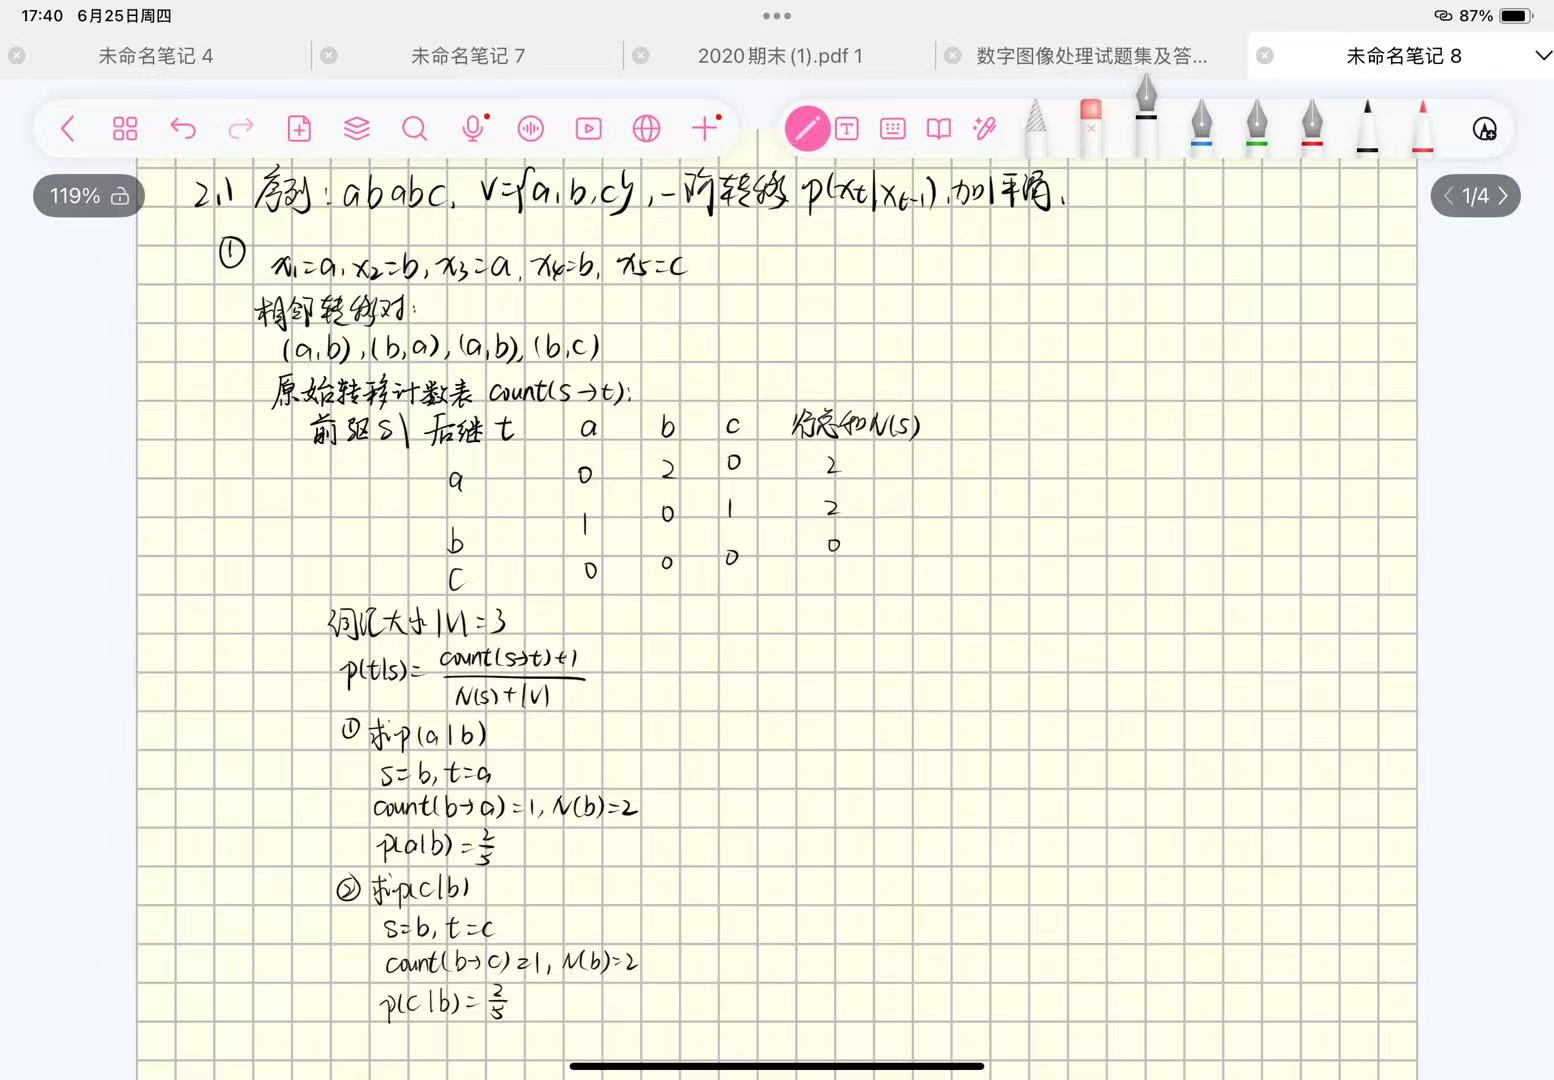


In [ ]:
import string
from collections import Counter

def preprocess_text(text, n):
    text_lower = text.lower()
    clean_chars = []
    for char in text_lower:
        if char.isalpha() or char == " ":
            clean_chars.append(char)
    clean_text = "".join(clean_chars)
    clean_text = " ".join(clean_text.split())

    word_list = clean_text.split()
    if len(word_list) <= n:
        return {}, ([], [])
    word_count = Counter(word_list)
    sorted_words = [word for word, cnt in word_count.most_common()]
    # 分配ID，从0开始
    word2id = {word: idx for idx, word in enumerate(sorted_words)}
    features = []
    labels = []
    max_start = len(word_list) - n
    for i in range(max_start):
        window = word_list[i:i+n]
        next_word = word_list[i + n]
        features.append(window)
        labels.append(next_word)
    return word2id, (features, labels)

In [ ]:

text_input = "The time machine"
n_win = 2
vocab, (feat, lab) = preprocess_text(text_input, n_win)

print("词汇表 word2id：", vocab)
print("特征列表 features：", feat)
print("标签列表 labels：", lab)

词汇表 word2id： {'the': 0, 'time': 1, 'machine': 2}
特征列表 features： [['the', 'time']]
标签列表 labels： ['machine']


In [3]:
test_text = "Hello! The time, machine. The time flies fast!"
n = 2
vocab, (feat, lab) = preprocess_text(test_text, n)
print("清洗后单词列表：", test_text.lower().translate(str.maketrans('', '', string.punctuation)).split())
print("词汇表(按频率)：", vocab)
print("特征：", feat)
print("标签：", lab)

清洗后单词列表： ['hello', 'the', 'time', 'machine', 'the', 'time', 'flies', 'fast']
词汇表(按频率)： {'the': 0, 'time': 1, 'hello': 2, 'machine': 3, 'flies': 4, 'fast': 5}
特征： [['hello', 'the'], ['the', 'time'], ['time', 'machine'], ['machine', 'the'], ['the', 'time'], ['time', 'flies']]
标签： ['time', 'machine', 'the', 'time', 'flies', 'fast']


03-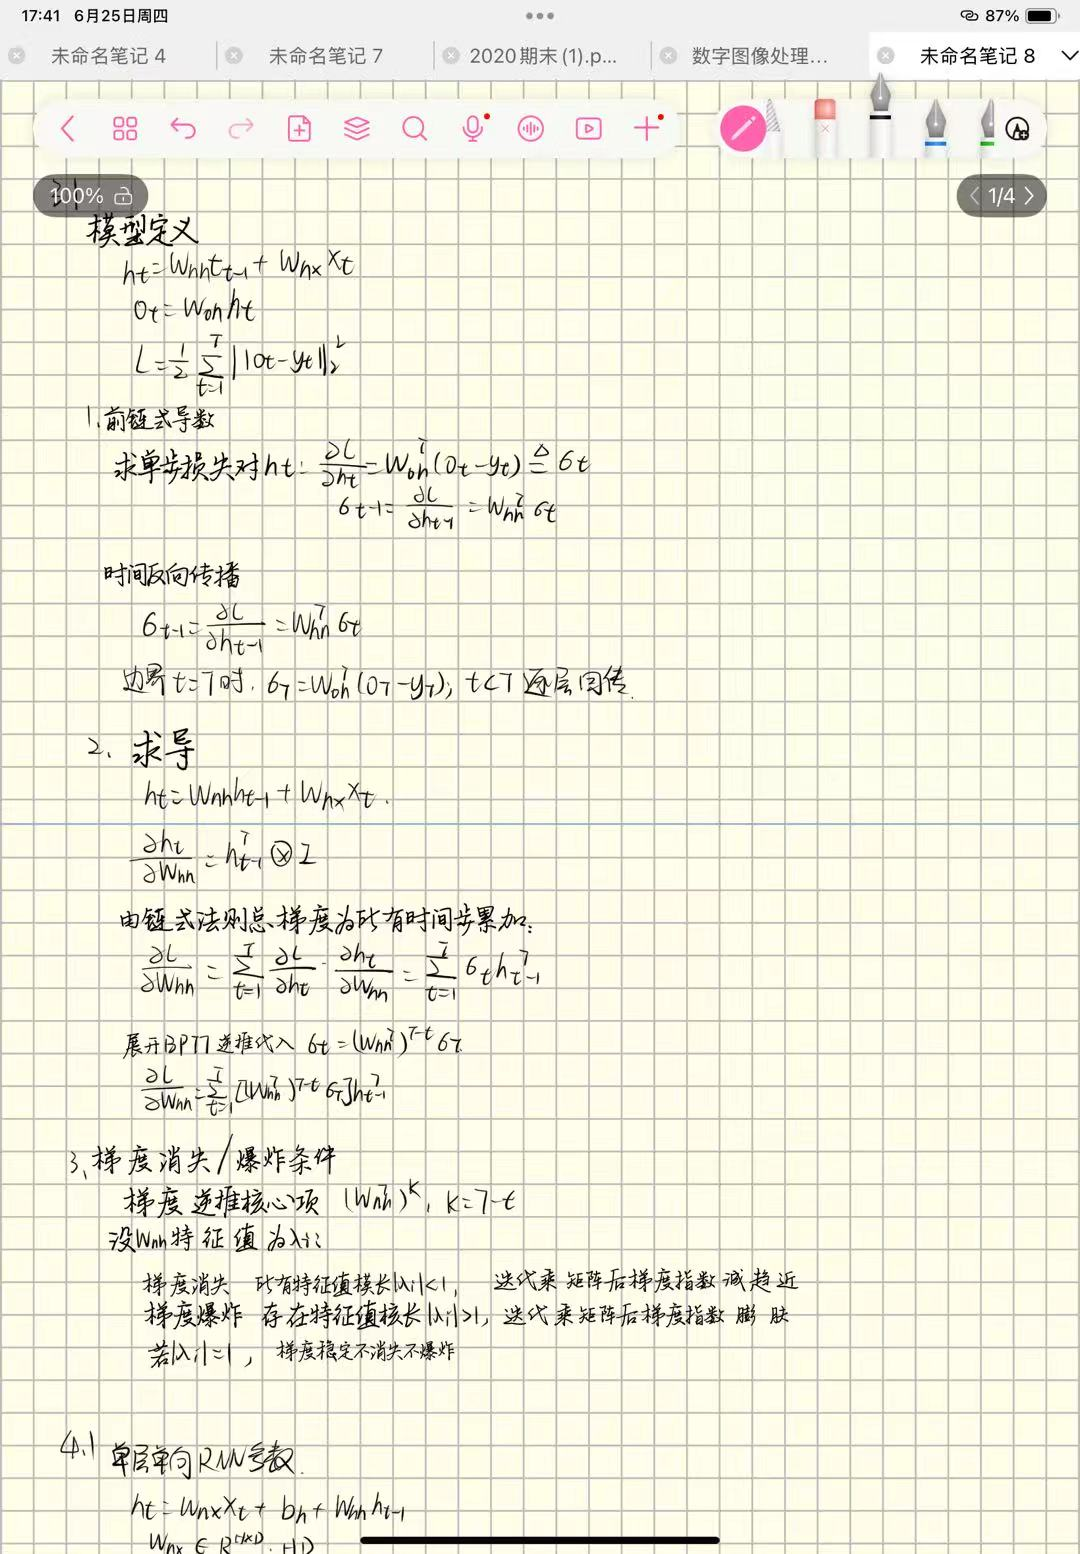

In [4]:
import numpy as np

def rnn_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    RNN单步前向传播
    参数：
        x_t: (B, input_size)
        h_prev: (B, hidden_size)
        W_hx: (hidden_size, input_size)
        W_hh: (hidden_size, hidden_size)
        b_h: (1, hidden_size)
    返回：
        h_t: 当前隐状态 (B, H)
        cache: 反向传播需要保存的中间变量 (x_t, h_prev, z_t, h_t)
    """
    # 计算线性组合 z_t = xW_hx.T + h_prev W_hh.T + b_h
    z_t = x_t @ W_hx.T + h_prev @ W_hh.T + b_h
    h_t = np.tanh(z_t)
    cache = (x_t, h_prev, z_t, h_t)
    return h_t, cache


def rnn_backward(dh_next, cache, W_hx, W_hh):
    """
    RNN单步反向传播，仅计算梯度，不更新参数
    参数：
        dh_next: 上游梯度 dL/dh_t, shape (B, H)
        cache: 前向保存的中间变量 (x_t, h_prev, z_t, h_t)
        W_hx, W_hh: 权重矩阵
    返回：
        dx_t, dh_prev, dW_hx, dW_hh, db_h
    """
    x_t, h_prev, z_t, h_t = cache
    B = x_t.shape[0]

    # 1. tanh导数 dz_t = dh_next ⊙ (1 - h_t^2)
    dz_t = dh_next * (1 - h_t ** 2)  # 逐元素相乘

    # 2. dL/dx_t = dz_t @ W_hx
    dx_t = dz_t @ W_hx

    # 3. dL/dh_prev = dz_t @ W_hh
    dh_prev = dz_t @ W_hh

    # 4. dW_hx = dz_t.T @ x_t
    dW_hx = dz_t.T @ x_t

    # 5. dW_hh = dz_t.T @ h_prev
    dW_hh = dz_t.T @ h_prev

    # 6. db_h：batch维度求和
    db_h = np.sum(dz_t, axis=0, keepdims=True)

    return dx_t, dh_prev, dW_hx, dW_hh, db_h

In [ ]:
# 超参数设置
batch_size = 2
input_size = 3
hidden_size = 4

# 随机初始化输入、隐状态
x_t = np.random.randn(batch_size, input_size)
h_prev = np.random.randn(batch_size, hidden_size)

# 初始化权重与偏置
W_hx = np.random.randn(hidden_size, input_size)
W_hh = np.random.randn(hidden_size, hidden_size)
b_h = np.zeros((1, hidden_size))

# 1. 前向传播
h_t, cache = rnn_forward(x_t, h_prev, W_hx, W_hh, b_h)
print("===== 前向传播结果 =====")
print(f"h_t shape: {h_t.shape}")
print("h_t:\n", h_t)

dh_next = np.random.randn(batch_size, hidden_size)

# 2. 反向传播求所有梯度
dx_t, dh_prev, dW_hx, dW_hh, db_h = rnn_backward(dh_next, cache, W_hx, W_hh)
print("\n===== 反向传播各梯度形状 =====")
print(f"dx_t shape: {dx_t.shape}")
print(f"dh_prev shape: {dh_prev.shape}")
print(f"dW_hx shape: {dW_hx.shape}")
print(f"dW_hh shape: {dW_hh.shape}")
print(f"db_h shape: {db_h.shape}")

===== 前向传播结果 =====
h_t shape: (2, 4)
h_t:
 [[-0.97435442  0.16297574 -0.13130457  0.99832595]
 [-0.99958605  0.15557095 -0.64604616 -0.95324754]]

===== 反向传播各梯度形状 =====
dx_t shape: (2, 3)
dh_prev shape: (2, 4)
dW_hx shape: (4, 3)
dW_hh shape: (4, 4)
db_h shape: (1, 4)


04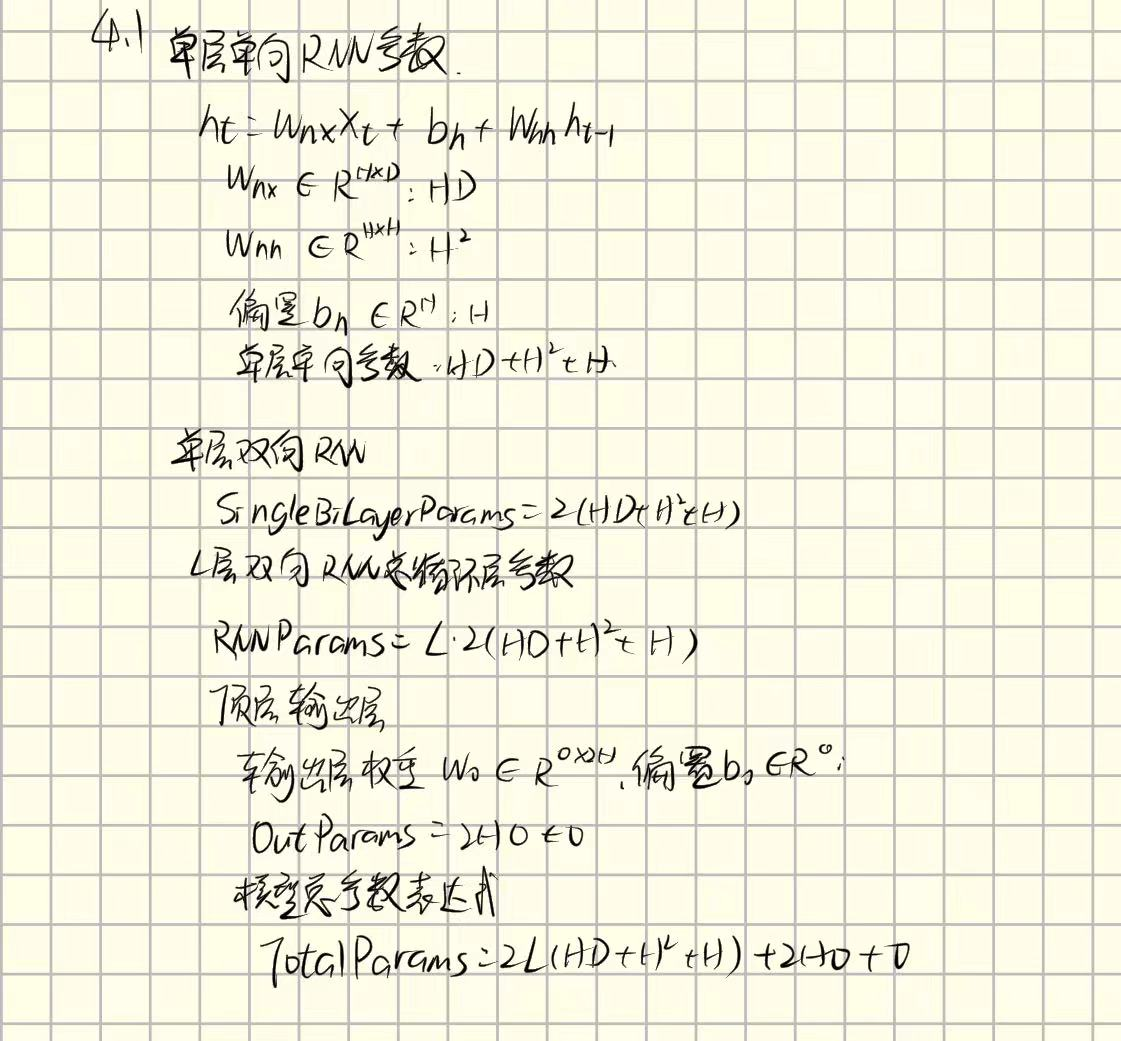

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class BiRNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=False  # 输入格式 (seq_len, batch, input_dim)
        )

    def forward(self, X):
        """
        X: (seq_len, batch, input_dim)
        return:
            all_hidden: (seq_len, batch, 2*hidden_dim) 每个时间步拼接前向+后向
            final_hidden: (batch, 2*hidden_dim) 首尾隐状态拼接
        """
        all_hidden, hidden = self.rnn(X)

        h_forward = hidden[0]  # (batch, hidden_dim)
        h_backward = hidden[1] # (batch, hidden_dim)
        final_hidden = torch.cat([h_forward, h_backward], dim=-1) # (batch, 2H)

        return all_hidden, final_hidden

# 测试代码
if __name__ == "__main__":
    seq_len, batch, input_dim = 5, 3, 4
    hidden_dim = 6
    model = BiRNNEncoder(input_dim, hidden_dim)
    X = torch.randn(seq_len, batch, input_dim)
    all_h, final_h = model(X)
    print("all_hidden shape:", all_h.shape)  # (5,3,12)
    print("final_hidden shape:", final_h.shape) # (3,12)

all_hidden shape: torch.Size([5, 3, 12])
final_hidden shape: torch.Size([3, 12])


05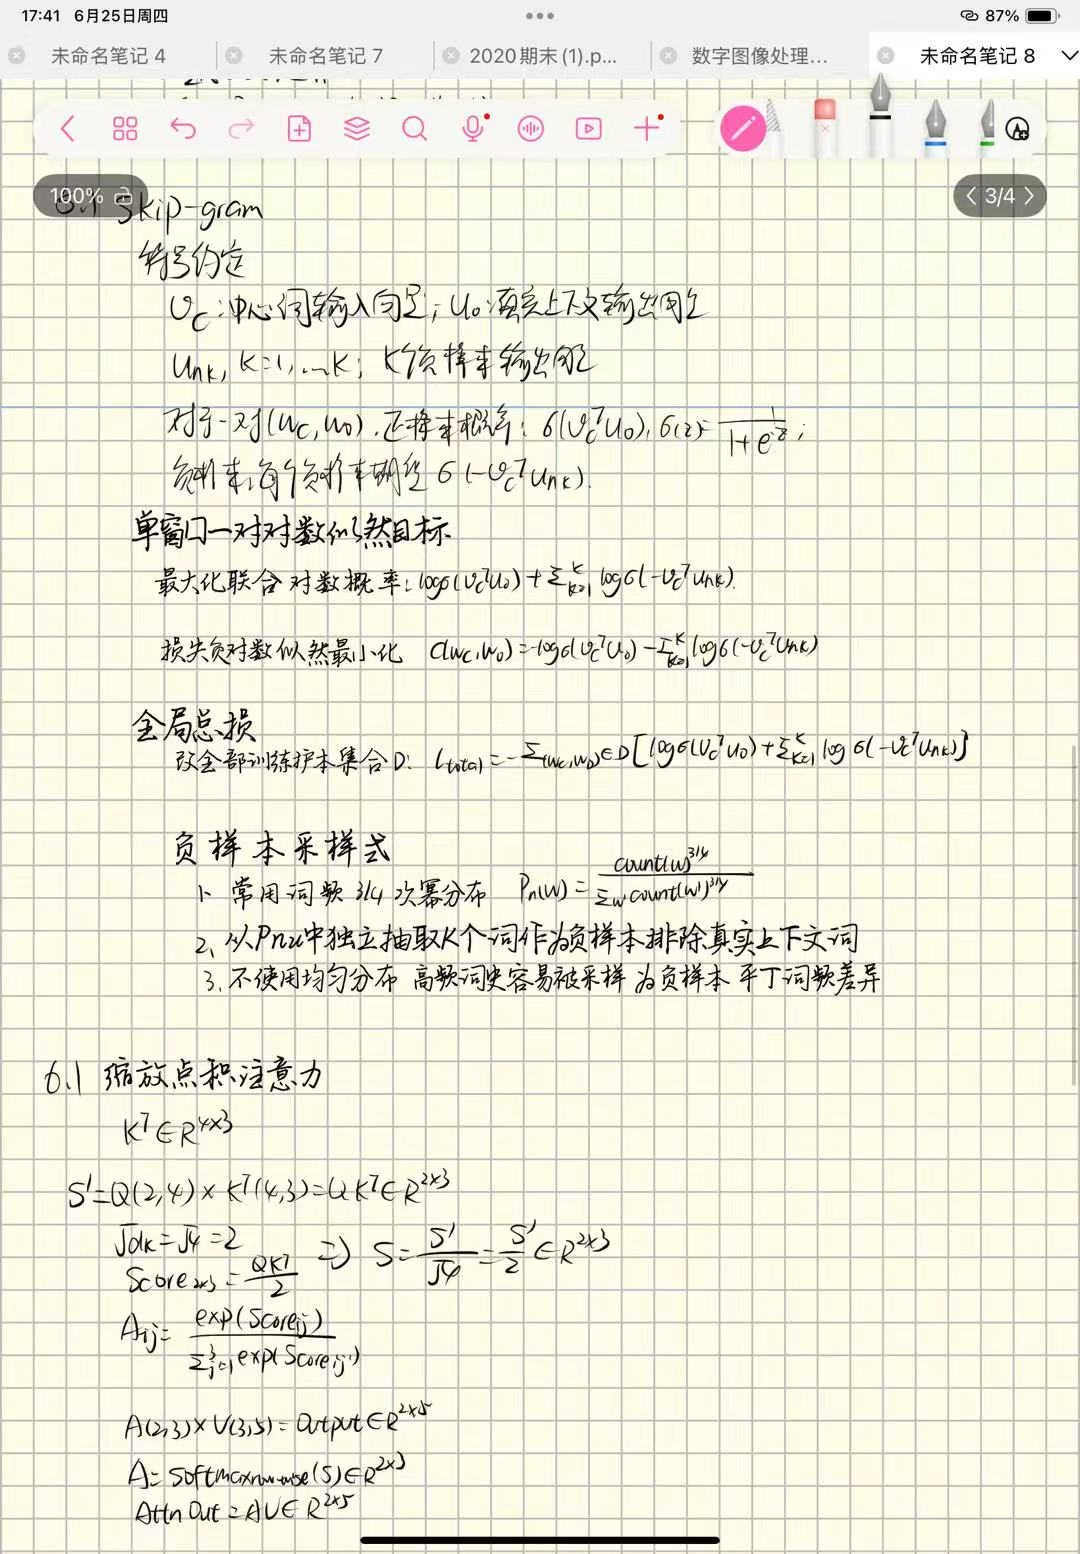

In [9]:
def cbow_forward_loss(context_indices, target, W, W_out):
    """
    参数：
        context_indices: (batch, context_size) 一批样本的上下文词索引
        target: (batch,) 每个样本的中心词索引
        W: (V, d) 嵌入矩阵
        W_out: (d, V) 输出权重
    返回：
        loss: 标量交叉熵损失
    """
    batch, context_size = context_indices.shape
    d = W.shape[1]

    # 1. 取出所有上下文嵌入 (batch, context_size, d)
    context_emb = W[context_indices]
    # 2. 上下文向量求均值得到隐藏层 (batch, d)
    h = torch.mean(context_emb, dim=1)
    # 3. 计算得分 (batch, V)
    score = h @ W_out
    # 4. 交叉熵损失（内置softmax）
    loss = F.cross_entropy(score, target)
    return loss

# 测试代码
if __name__ == "__main__":
    V = 100  # 词汇量
    d = 8    # 嵌入维度
    batch = 4
    context_size = 2

    W = torch.randn(V, d)
    W_out = torch.randn(d, V)
    context_idx = torch.randint(0, V, (batch, context_size))
    target = torch.randint(0, V, (batch,))

    loss = cbow_forward_loss(context_idx, target, W, W_out)
    print("CBOW loss value:", loss.item())

CBOW loss value: 7.651288986206055


In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.num_heads = 2
        self.d_model = 4
        self.d_k = self.d_v = self.d_model // self.num_heads  # 2

        # QKV 投影层
        self.w_q = nn.Linear(self.d_model, self.d_model)
        self.w_k = nn.Linear(self.d_model, self.d_model)
        self.w_v = nn.Linear(self.d_model, self.d_model)
        # 输出融合线性层
        self.w_o = nn.Linear(self.d_model, self.d_model)

    def scaled_dot_product_attn(self, q, k, v):
        """单头缩放点积注意力
        q,k,v: (seq_len, batch, d_k)
        """
        attn_score = torch.matmul(q, k.transpose(-1, -2)) / torch.sqrt(torch.tensor(self.d_k, dtype=torch.float32))
        attn_weight = F.softmax(attn_score, dim=-1)
        out = torch.matmul(attn_weight, v)
        return out

    def split_heads(self, x):
        """(seq_len, batch, d_model) -> (num_heads, seq_len, batch, d_k)"""
        seq_len, batch, _ = x.shape
        return x.view(seq_len, batch, self.num_heads, self.d_k).permute(2, 0, 1, 3)

    def concat_heads(self, x):
        """(num_heads, seq_len, batch, d_k) -> (seq_len, batch, d_model)"""
        num_h, seq_len, batch, _ = x.shape
        return x.permute(1, 2, 0, 3).reshape(seq_len, batch, self.d_model)

    def forward(self, X):
        """
        X: (seq_len, batch, d_model=4)
        return out: (seq_len, batch, 4)
        """
        seq_len, batch, _ = X.shape
        # 1. 投影Q K V
        Q = self.w_q(X)
        K = self.w_k(X)
        V = self.w_v(X)

        # 2. 分头
        Q_split = self.split_heads(Q)  # (2, seq, batch, 2)
        K_split = self.split_heads(K)
        V_split = self.split_heads(V)

        # 3. 每个头单独计算注意力
        head_outputs = []
        for h in range(self.num_heads):
            qh = Q_split[h]
            kh = K_split[h]
            vh = V_split[h]
            head_out = self.scaled_dot_product_attn(qh, kh, vh)
            head_outputs.append(head_out)
        heads_out = torch.stack(head_outputs, dim=0)  # (2, seq, batch, 2)

        # 4. 拼接多头
        concat = self.concat_heads(heads_out)
        # 5. 最终线性层
        out = self.w_o(concat)
        return out

# 测试代码
if __name__ == "__main__":
    mha = MultiHeadAttention()
    seq_len, batch = 6, 2
    X = torch.randn(seq_len, batch, 4)
    res = mha(X)
    print("MHA output shape:", res.shape) # (6, 2, 4)

MHA output shape: torch.Size([6, 2, 4])
